# Notebook 13 — Fine-Tuning del Clasificador de Género
Entrenamiento de DistilBERT multilingüe para clasificar Rock / Hip-Hop / Metal.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
from src.Proyecto_3.finetuning_utils import preparar_dataset,entrenar_clasificador, evaluar_modelo, cargar_clasificador, predecir_genero, GENEROS_TARGET


df = pd.read_csv('../data//processed/lyrics_clean.csv')
df_target = df[df['Genre'].isin(GENEROS_TARGET)].copy()
print(f'Canciones para fine-tuning: {len(df_target)}')
print(df_target['Genre'].value_counts())

Canciones para fine-tuning: 3180
Genre
Rock       1410
Hip-Hop     960
Metal       810
Name: count, dtype: int64


In [2]:
# Preparar datasets train/val/test (70/15/15)
ds_train, ds_val, ds_test, le = preparar_dataset(
    df_target, text_col='Lyrics', label_col='Genre'
)
num_labels = len(le.classes_)
print(f'Número de clases: {num_labels} — {le.classes_.tolist()}')

C:\Users\Roberto\Analisis-Morfosintactico-de-Letras-Musicales\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 2226 | Val: 477 | Test: 477
Clases: ['Hip-Hop', 'Metal', 'Rock']


Número de clases: 3 — ['Hip-Hop', 'Metal', 'Rock']


## Baseline Zero-Shot (sin fine-tuning)

In [3]:
from transformers import pipeline as hf_pipeline
from sklearn.metrics import accuracy_score, f1_score

# Zero-shot baseline con el modelo base sin fine-tuning
zs = hf_pipeline('zero-shot-classification',
                  model='distilbert-base-multilingual-cased',
                  device=-1)

muestra = df_target.sample(100, random_state=42)
preds_zs = []
for texto in muestra['Lyrics'].astype(str).str[:200]:
    res = zs(texto, candidate_labels=GENEROS_TARGET)
    preds_zs.append(res['labels'][0])

labels_zs = muestra['Genre'].tolist()
acc_zs = accuracy_score(labels_zs, preds_zs)
f1_zs  = f1_score(labels_zs, preds_zs, average='macro', zero_division=0)
print(f'Zero-Shot Accuracy: {acc_zs:.4f}')
print(f'Zero-Shot F1 Macro: {f1_zs:.4f}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9310.54it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model

Zero-Shot Accuracy: 0.4600
Zero-Shot F1 Macro: 0.2100


## Fine-Tuning (3 épocas)

In [4]:
trainer, model = entrenar_clasificador(ds_train, ds_val, num_labels, num_epochs=3)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8315.93it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Iniciando fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.714942,0.778848,0.708595,0.684896
2,0.528676,0.826613,0.733753,0.733830
3,0.367583,0.870374,0.737945,0.737291


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.81it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.08s/it]

Modelo guardado en C:\Analisis-Morfosintactico-de-Letras-Musicales\src\Proyecto_3\..\models\clasificador_genero


In [5]:
# Evaluación sobre test
metricas = evaluar_modelo(trainer, ds_test, le)

print(f'\n=== COMPARACIÓN ===')
print(f'Zero-Shot  — Accuracy: {acc_zs:.4f} | F1: {f1_zs:.4f}')
print(f'Fine-Tuned — Accuracy: {metricas["accuracy"]:.4f} | F1: {metricas["f1_macro"]:.4f}')
print(f'Ganancia   — Accuracy: +{metricas["accuracy"]-acc_zs:.4f} | F1: +{metricas["f1_macro"]-f1_zs:.4f}')

# Guardar métricas
os.makedirs('../resultados', exist_ok=True)
metricas['zero_shot_accuracy'] = acc_zs
metricas['zero_shot_f1']       = f1_zs
with open('../resultados/metricas.json', 'w') as f:
    json.dump(metricas, f, indent=2)
print('Métricas guardadas en resultados/metricas.json')


Test Accuracy : 0.7820
Test F1 Macro : 0.7829
Clases        : ['Hip-Hop', 'Metal', 'Rock']
Matriz de confusión:
[[117   2  25]
 [  4  93  25]
 [ 12  36 163]]

=== COMPARACIÓN ===
Zero-Shot  — Accuracy: 0.4600 | F1: 0.2100
Fine-Tuned — Accuracy: 0.7820 | F1: 0.7829
Ganancia   — Accuracy: +0.3220 | F1: +0.5729
Métricas guardadas en resultados/metricas.json


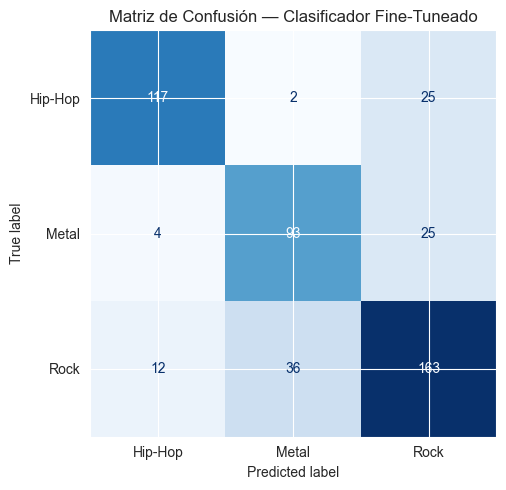

In [6]:
# Matriz de confusión
cm = np.array(metricas['confusion_matrix'])
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=metricas['classes'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — Clasificador Fine-Tuneado')
plt.tight_layout()
plt.savefig('../resultados/confusion_matrix.png', dpi=150)
plt.show()

In [7]:
# Pruebas de inferencia
ejemplos = [
    'I rage against the machine, break the chains of society',
    'In the streets of the hood, hustling for my crew',
    'Death and darkness consume my soul, metal rising from the ground',
]
for e in ejemplos:
    genero = predecir_genero(e)
    print(f'  "{e[:60]}..." → {genero}')

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7415.85it/s]

  "I rage against the machine, break the chains of society..." → Rock
  "In the streets of the hood, hustling for my crew..." → Rock
  "Death and darkness consume my soul, metal rising from the gr..." → Rock
